In [20]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [21]:
# define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [22]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi,2)

    return state

In [25]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = 'Underweight'    
    elif 18.5 <= bmi < 25:
        state["category"] = 'Normal'
    elif bmi < 30:
        state["category"] = 'Overweight'
    else:
        state["category"] = 'Obese'

    return state

In [ ]:
# define graph

graph= StateGraph(BMIState)

# adding nodes

graph.add_node('Calculate_bmi', calculate_bmi)
graph.add_node('Label_bmi',label_bmi)

# adding edges

graph.add_edge(START, 'Calculate_bmi')
graph.add_edge('Calculate_bmi', 'Label_bmi')
graph.add_edge('Label_bmi', END)

# Compiling graph

workflow = graph.compile()

# Execute the graph

initial_state = {'weight_kg': 70, 'height_m': 1.75}


final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86, 'category': 'Normal'}


: 

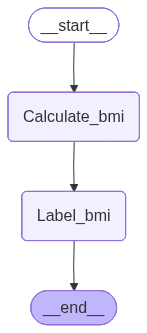

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())